In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# DataSource: https://www.kaggle.com/datasets/shahp7575/horoscopes
# Load dataset
df = pd.read_csv("../data/horoscope_saved.csv")

# Preview dataset
df.head()

,sign,category,date,horoscope
0,aries,general,20200617,"There's a great day ahead of you, Aries. You'l..."
1,aries,general,20200618,People will understand and appreciate your des...
2,aries,general,20200619,You are very interested in technological break...
3,aries,general,20200620,Stress from overwork could have you feeling we...
4,aries,general,20200621,This is a good day to stand up for yourself an...


#### Understand the Dataset

In [92]:
display(df.head())

,sign,category,date,horoscope
0,aries,general,20200617,"There's a great day ahead of you, Aries. You'l..."
1,aries,general,20200618,People will understand and appreciate your des...
2,aries,general,20200619,You are very interested in technological break...
3,aries,general,20200620,Stress from overwork could have you feeling we...
4,aries,general,20200621,This is a good day to stand up for yourself an...


In [93]:
# General information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21959 entries, 0 to 21958
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sign       21959 non-null  object
 1   category   21959 non-null  object
 2   date       21959 non-null  int64 
 3   horoscope  21959 non-null  object
dtypes: int64(1), object(3)
memory usage: 686.3+ KB


In [94]:
# Basic statistics
df.describe(include='all')

,sign,category,date,horoscope
count,21959,21959,2.195900e+04,21959
unique,12,5,NaN,12050
top,taurus,love,NaN,Career and your public image may be important ...
freq,1830,4392,NaN,12
mean,NaN,NaN,2.020523e+07,NaN
std,NaN,NaN,4.688102e+03,NaN
min,NaN,NaN,2.020062e+07,NaN
25%,NaN,NaN,2.020092e+07,NaN
50%,NaN,NaN,2.020122e+07,NaN
75%,NaN,NaN,2.021032e+07,NaN


#### Convert Dates Properly

In [95]:
df["date"] = pd.to_datetime(df["date"], format="%Y%m%d")

In [96]:
df.head()

,sign,category,date,horoscope
0,aries,general,2020-06-17,"There's a great day ahead of you, Aries. You'l..."
1,aries,general,2020-06-18,People will understand and appreciate your des...
2,aries,general,2020-06-19,You are very interested in technological break...
3,aries,general,2020-06-20,Stress from overwork could have you feeling we...
4,aries,general,2020-06-21,This is a good day to stand up for yourself an...


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21959 entries, 0 to 21958
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   sign       21959 non-null  object        
 1   category   21959 non-null  object        
 2   date       21959 non-null  datetime64[ns]
 3   horoscope  21959 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 686.3+ KB


In [98]:
df["category"].value_counts()

category
love        4392
wellness    4392
career      4392
birthday    4392
general     4391
Name: count, dtype: int64

#### Add Mercury Retrograde Labels

In [102]:
# Dataset mercury retrograde periods (2020 and 2021)
retrograde_periods = [
    # 2020
    ('2020-06-18', '2020-07-12'),
    ('2020-10-14', '2020-11-03'),
    # 2021
    ('2021-01-30', '2021-02-20'),
    ('2021-05-29', '2021-06-22')
]

In [103]:
# Function to check if a date comes under retrograde period
def is_retrograde(date):
    for start, end in retrograde_periods:
        if pd.to_datetime(start) <= date <= pd.to_datetime(end):
            return 1
    return 0

In [104]:
df['retrograde'] = df['date'].apply(is_retrograde)

In [105]:
df[['date', 'retrograde']].head(10)

,date,retrograde
0,2020-06-17,0
1,2020-06-18,1
2,2020-06-19,1
3,2020-06-20,1
4,2020-06-21,1
5,2020-06-22,1
6,2020-06-23,1
7,2020-06-24,1
8,2020-06-25,1
9,2020-06-26,1


In [106]:
df["retrograde"].value_counts()

retrograde
0    16739
1     5220
Name: count, dtype: int64

#### Clean the Horoscope Text

In [108]:
import re

# text cleaning function
def clean_text(text):
    text = text.lower()
    # remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    return text

In [109]:
# Apply the function and create a new clean txt column
df['clean_horoscope'] = df['horoscope'].apply(clean_text)

# View results and compare columns
df[['horoscope', 'clean_horoscope']].head()

,horoscope,clean_horoscope
0,"There's a great day ahead of you, Aries. You'l...",theres a great day ahead of you aries youll be...
1,People will understand and appreciate your des...,people will understand and appreciate your des...
2,You are very interested in technological break...,you are very interested in technological break...
3,Stress from overwork could have you feeling we...,stress from overwork could have you feeling we...
4,This is a good day to stand up for yourself an...,this is a good day to stand up for yourself an...


#### VADER

In [110]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

In [111]:
# Download VADER lexicon (only once)
# nltk.download('vader_lexicon')

In [112]:
sia = SentimentIntensityAnalyzer()

In [113]:
# testing example
text = "Today you will feel happy and achieve great success."

# get sentiment scores
scores = sia.polarity_scores(text)

print(scores)

{'neg': 0.0, 'neu': 0.343, 'pos': 0.657, 'compound': 0.91}


In [114]:
text2 = "Today will bring difficulties and misunderstandings."

print(sia.polarity_scores(text2))

{'neg': 0.306, 'neu': 0.694, 'pos': 0.0, 'compound': -0.296}


In [115]:
# apply sentiment analysis to clean_text column

# create a new column for sentiment scores
df['sentiment'] = df['clean_horoscope'].apply(lambda x: sia.polarity_scores(x)['compound'])

In [116]:
df.head()

,sign,category,date,horoscope,retrograde,clean_horoscope,sentiment
0,aries,general,2020-06-17,"There's a great day ahead of you, Aries. You'l...",0,theres a great day ahead of you aries youll be...,0.9403
1,aries,general,2020-06-18,People will understand and appreciate your des...,1,people will understand and appreciate your des...,0.9781
2,aries,general,2020-06-19,You are very interested in technological break...,1,you are very interested in technological break...,0.9509
3,aries,general,2020-06-20,Stress from overwork could have you feeling we...,1,stress from overwork could have you feeling we...,-0.6804
4,aries,general,2020-06-21,This is a good day to stand up for yourself an...,1,this is a good day to stand up for yourself an...,0.8319


##### Convert Sentiment Into Categories

In [119]:
# function to classify sentiment by score
def classify_sentiment(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

# apply classification function to all rows
df['sentiment_label'] = df['sentiment'].apply(classify_sentiment)

df[['sentiment', 'sentiment_label']].head()

,sentiment,sentiment_label
0,0.9403,positive
1,0.9781,positive
2,0.9509,positive
3,-0.6804,negative
4,0.8319,positive


##### Analyze Sentiment Distribution

In [123]:
# count how many of each sentiment type
sentiment_counts = df['sentiment_label'].value_counts()

print(sentiment_counts)


sentiment_label
positive    19571
negative     2049
neutral       339
Name: count, dtype: int64


In [124]:
# convert counts to percentage
sentiment_percent = df['sentiment_label'].value_counts(normalize=True) * 100

print(sentiment_percent)

sentiment_label
positive    89.125188
negative     9.331026
neutral      1.543786
Name: proportion, dtype: float64


##### Compare Sentiment (Retrograde vs Normal)

In [125]:
# count how many of each sentiment type group by retrograde
retrograde_sentiment_counts = df.groupby('retrograde')['sentiment_label'].value_counts()

print(retrograde_sentiment_counts)

retrograde  sentiment_label
0           positive           14937
            negative            1531
            neutral              271
1           positive            4634
            negative             518
            neutral               68
Name: count, dtype: int64


In [126]:
# calculate average sentiment for each group
sentiment_comparison = df.groupby('retrograde')['sentiment'].mean()

print(sentiment_comparison)

retrograde
0    0.693613
1    0.677637
Name: sentiment, dtype: float64


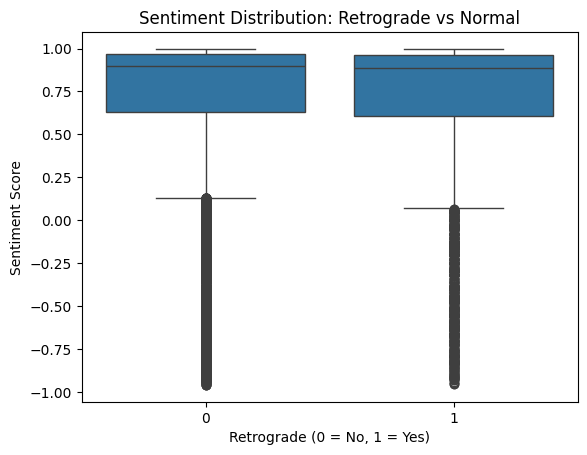

In [127]:
# plot comparison
sns.boxplot(x='retrograde', y='sentiment', data=df)

plt.title("Sentiment Distribution: Retrograde vs Normal")
plt.xlabel("Retrograde (0 = No, 1 = Yes)")
plt.ylabel("Sentiment Score")

plt.show()

#### RoBERTa

In [128]:
from transformers import pipeline
import torch



In [129]:
sentiment_model = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment-latest")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [130]:
sample_text = df["horoscope"].iloc[0]

sentiment_model(sample_text)

[{'label': 'positive', 'score': 0.9629408121109009}]

In [131]:
def get_sentiment(text):
    # limit text length for safety
    # result = sentiment_model(text[:512])[0]
    result =  sentiment_model(text)[0]
    return result["label"], result["score"]

In [132]:
get_sentiment(df["horoscope"].iloc[0])

('positive', 0.9629408121109009)

In [133]:
# testing the process on first 100 rows initially
sample_df = df.head(100).copy()

sample_df["sentiment"] = sample_df["horoscope"].apply(get_sentiment)

sample_df.head()

,sign,category,date,horoscope,retrograde,clean_horoscope,sentiment,sentiment_label
0,aries,general,2020-06-17,"There's a great day ahead of you, Aries. You'l...",0,theres a great day ahead of you aries youll be...,"(positive, 0.9629408121109009)",positive
1,aries,general,2020-06-18,People will understand and appreciate your des...,1,people will understand and appreciate your des...,"(positive, 0.8029679656028748)",positive
2,aries,general,2020-06-19,You are very interested in technological break...,1,you are very interested in technological break...,"(positive, 0.9139738082885742)",positive
3,aries,general,2020-06-20,Stress from overwork could have you feeling we...,1,stress from overwork could have you feeling we...,"(negative, 0.4843314290046692)",negative
4,aries,general,2020-06-21,This is a good day to stand up for yourself an...,1,this is a good day to stand up for yourself an...,"(positive, 0.8959439992904663)",positive


In [134]:
sample_df["sentiment_label"] = sample_df["sentiment"].apply(lambda x: x[0])
sample_df["sentiment_score"] = sample_df["sentiment"].apply(lambda x: x[1])

sample_df.drop(columns=["sentiment"], inplace=True)

sample_df.head()

,sign,category,date,horoscope,retrograde,clean_horoscope,sentiment_label,sentiment_score
0,aries,general,2020-06-17,"There's a great day ahead of you, Aries. You'l...",0,theres a great day ahead of you aries youll be...,positive,0.962941
1,aries,general,2020-06-18,People will understand and appreciate your des...,1,people will understand and appreciate your des...,positive,0.802968
2,aries,general,2020-06-19,You are very interested in technological break...,1,you are very interested in technological break...,positive,0.913974
3,aries,general,2020-06-20,Stress from overwork could have you feeling we...,1,stress from overwork could have you feeling we...,negative,0.484331
4,aries,general,2020-06-21,This is a good day to stand up for yourself an...,1,this is a good day to stand up for yourself an...,positive,0.895944


In [135]:
# clearing these columns before running the model on all rows
df["sentiment_label"] = None
df["sentiment_score"] = None

In [136]:
batch_size = 500

for i in range(0, len(df), batch_size):
    batch = df.iloc[i:i+batch_size].copy()
    
    results = batch["horoscope"].apply(get_sentiment)
    
    df.loc[batch.index, "sentiment_label"] = results.apply(lambda x: x[0])
    df.loc[batch.index, "sentiment_score"] = results.apply(lambda x: x[1])
    
    print(f"Processed: {i} to {i+batch_size}")

Processed: 0 to 500
Processed: 500 to 1000
Processed: 1000 to 1500
Processed: 1500 to 2000
Processed: 2000 to 2500
Processed: 2500 to 3000
Processed: 3000 to 3500
Processed: 3500 to 4000
Processed: 4000 to 4500
Processed: 4500 to 5000
Processed: 5000 to 5500
Processed: 5500 to 6000
Processed: 6000 to 6500
Processed: 6500 to 7000
Processed: 7000 to 7500
Processed: 7500 to 8000
Processed: 8000 to 8500
Processed: 8500 to 9000
Processed: 9000 to 9500
Processed: 9500 to 10000
Processed: 10000 to 10500
Processed: 10500 to 11000
Processed: 11000 to 11500
Processed: 11500 to 12000
Processed: 12000 to 12500
Processed: 12500 to 13000
Processed: 13000 to 13500
Processed: 13500 to 14000
Processed: 14000 to 14500
Processed: 14500 to 15000
Processed: 15000 to 15500
Processed: 15500 to 16000
Processed: 16000 to 16500
Processed: 16500 to 17000
Processed: 17000 to 17500
Processed: 17500 to 18000
Processed: 18000 to 18500
Processed: 18500 to 19000
Processed: 19000 to 19500
Processed: 19500 to 20000
Proc

Due to computational constraints of transformer-based models, sentiment extraction was performed in batches to optimize memory usage and ensure stability.

In [137]:
def convert_sentiment(label, score):
    if label.lower() == "positive":
        return score
    elif label.lower() == "negative":
        return -score
    else:
        return 0

In [138]:
df.head()

,sign,category,date,horoscope,retrograde,clean_horoscope,sentiment,sentiment_label,sentiment_score
0,aries,general,2020-06-17,"There's a great day ahead of you, Aries. You'l...",0,theres a great day ahead of you aries youll be...,0.9403,positive,0.962941
1,aries,general,2020-06-18,People will understand and appreciate your des...,1,people will understand and appreciate your des...,0.9781,positive,0.802968
2,aries,general,2020-06-19,You are very interested in technological break...,1,you are very interested in technological break...,0.9509,positive,0.913974
3,aries,general,2020-06-20,Stress from overwork could have you feeling we...,1,stress from overwork could have you feeling we...,-0.6804,negative,0.484331
4,aries,general,2020-06-21,This is a good day to stand up for yourself an...,1,this is a good day to stand up for yourself an...,0.8319,positive,0.895944


In [139]:
df["sentiment_numeric"] = df.apply(lambda x: convert_sentiment(x["sentiment_label"], x["sentiment_score"]), axis=1)

In [140]:
df.head()

,sign,category,date,horoscope,retrograde,clean_horoscope,sentiment,sentiment_label,sentiment_score,sentiment_numeric
0,aries,general,2020-06-17,"There's a great day ahead of you, Aries. You'l...",0,theres a great day ahead of you aries youll be...,0.9403,positive,0.962941,0.962941
1,aries,general,2020-06-18,People will understand and appreciate your des...,1,people will understand and appreciate your des...,0.9781,positive,0.802968,0.802968
2,aries,general,2020-06-19,You are very interested in technological break...,1,you are very interested in technological break...,0.9509,positive,0.913974,0.913974
3,aries,general,2020-06-20,Stress from overwork could have you feeling we...,1,stress from overwork could have you feeling we...,-0.6804,negative,0.484331,-0.484331
4,aries,general,2020-06-21,This is a good day to stand up for yourself an...,1,this is a good day to stand up for yourself an...,0.8319,positive,0.895944,0.895944


In [141]:
df.groupby("retrograde")["sentiment_numeric"].mean()

retrograde
0    0.442279
1    0.432014
Name: sentiment_numeric, dtype: float64

Horoscopes are slightly more negative during Mercury retrograde but the difference is extremely small.

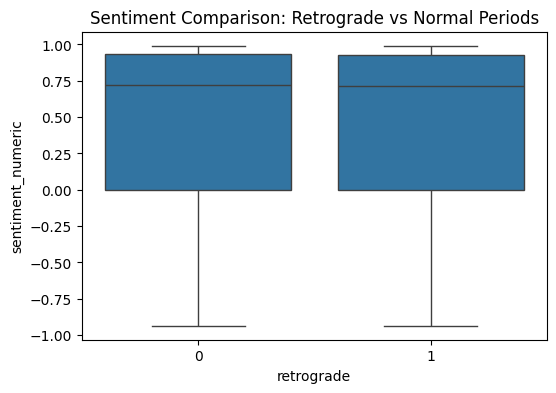

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x="retrograde", y="sentiment_numeric", data=df)
plt.title("Sentiment Comparison: Retrograde vs Normal Periods")
plt.show()